In [1]:
from utils.preprocess import preliminary_preproc, separate_data_shift_categories, preprocess_shift_categories_da
from utils.models import RFModel, XGBModel, LGBMModel, GBTModel, LogRegModel
import shap
import matplotlib.pyplot as plt

/Users/uladzimircharniauski/miniconda3/envs/ds_works/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
X, y, df = preliminary_preproc('./data/Telco_customer_churn.csv')

df_collection = separate_data_shift_categories(df)

# 1. Distribution Analysis 

In [3]:
def train_models_da(model_list, X_train, X_test, y_train, y_test, slice_name):

    trained_models = []

    for m in model_list:
        m.train(X_train, y_train)

        print(f"\nTesting {m.model_name} on {slice_name}:")
        m.evaluate(X_test, y_test)

        trained_models.append(m)

    return trained_models

In [4]:
def shap_diagnostics(model, X_test):
    """SHAP Diagnostics"""

    model_name = model.__class__.__name__
    if model_name != "LogisticRegression":
        print(model_name)

        explainer = shap.TreeExplainer(model)
        shap_values = explainer(X_test)

        if model_name == "RandomForestClassifier":
            shap_values = shap_values[:, :, 1]

        shap.plots.beeswarm(shap_values, show=False)

        plt.show()

In [5]:
model_list = [RFModel(), XGBModel(), LGBMModel(), GBTModel(), LogRegModel()]

### 1.1 Tenure Cohort

In [6]:
tenure_1 = ['Short','Medium']
tenure_2 = ['Medium','Long']

X_train_sm, X_test_sm, y_train_sm, y_test_sm, numeric_features, obj_features = preprocess_shift_categories_da(df_collection['Tenure'],['Long'], tenure_1)
X_train_ml, X_test_ml, y_train_ml, y_test_ml, numeric_features, obj_features = preprocess_shift_categories_da(df_collection['Tenure'],['Short'], tenure_2)

In [7]:
trained_models_sm = train_models_da(model_list, X_train_sm, X_test_sm, y_train_sm, y_test_sm, 'Long Tenure')


Testing DecisionTree/RF on Long Tenure:
--- DecisionTree/RF Evaluation ---
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      1314
           1       0.26      0.24      0.25        93

    accuracy                           0.90      1407
   macro avg       0.60      0.59      0.60      1407
weighted avg       0.90      0.90      0.90      1407


Testing XGBoost on Long Tenure:
--- XGBoost Evaluation ---
              precision    recall  f1-score   support

           0       0.95      0.90      0.93      1314
           1       0.18      0.29      0.22        93

    accuracy                           0.86      1407
   macro avg       0.56      0.60      0.57      1407
weighted avg       0.90      0.86      0.88      1407

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1776, number of negative: 3860
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the

In [8]:
trained_models_ml = train_models_da(model_list, X_train_ml, X_test_ml, y_train_ml, y_test_ml, 'Short Tenure')


Testing DecisionTree/RF on Short Tenure:
--- DecisionTree/RF Evaluation ---
              precision    recall  f1-score   support

           0       0.61      0.75      0.67      1149
           1       0.63      0.47      0.54      1037

    accuracy                           0.62      2186
   macro avg       0.62      0.61      0.61      2186
weighted avg       0.62      0.62      0.61      2186


Testing XGBoost on Short Tenure:
--- XGBoost Evaluation ---
              precision    recall  f1-score   support

           0       0.60      0.78      0.68      1149
           1       0.63      0.43      0.51      1037

    accuracy                           0.61      2186
   macro avg       0.62      0.60      0.59      2186
weighted avg       0.62      0.61      0.60      2186

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 832, number of negative: 4025
[LightGBM] [Info] Auto-choosing row-wise multi-threading, th

### SHAP Diagnostics

RandomForestClassifier


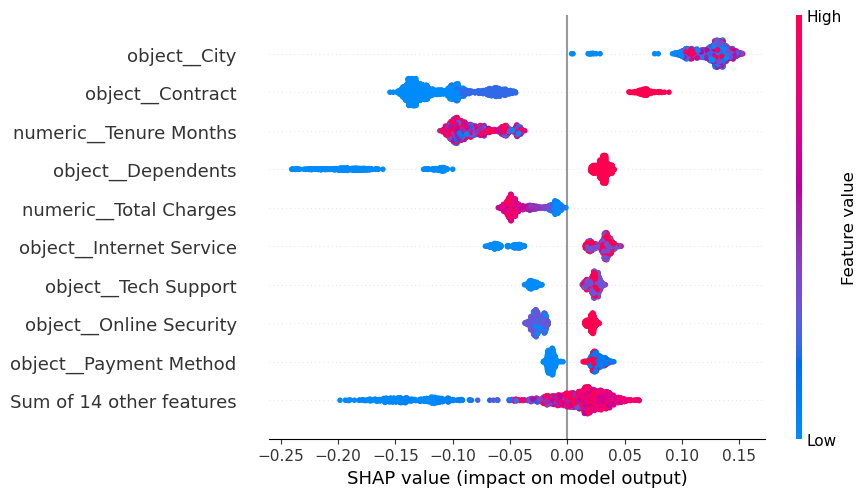

XGBClassifier


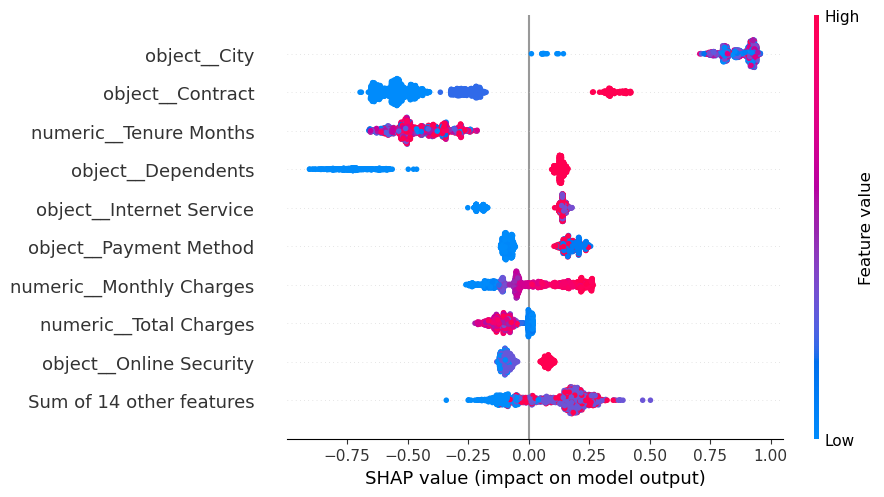

LGBMClassifier


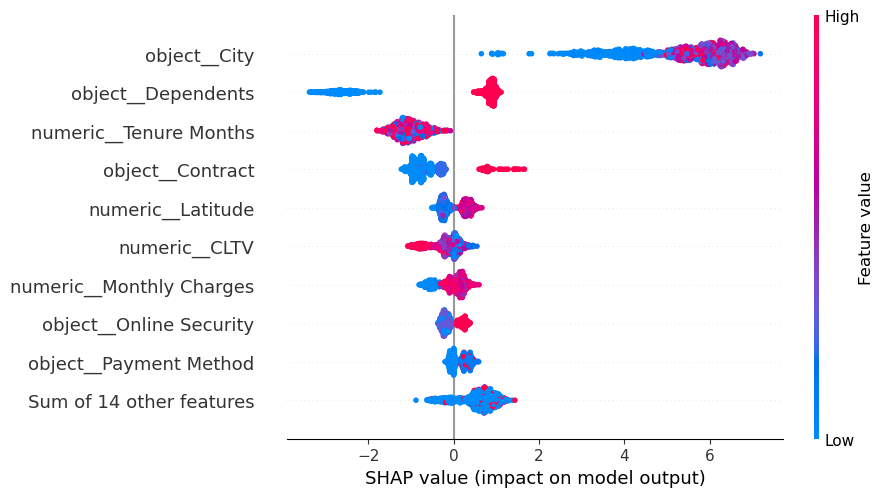

GradientBoostingClassifier


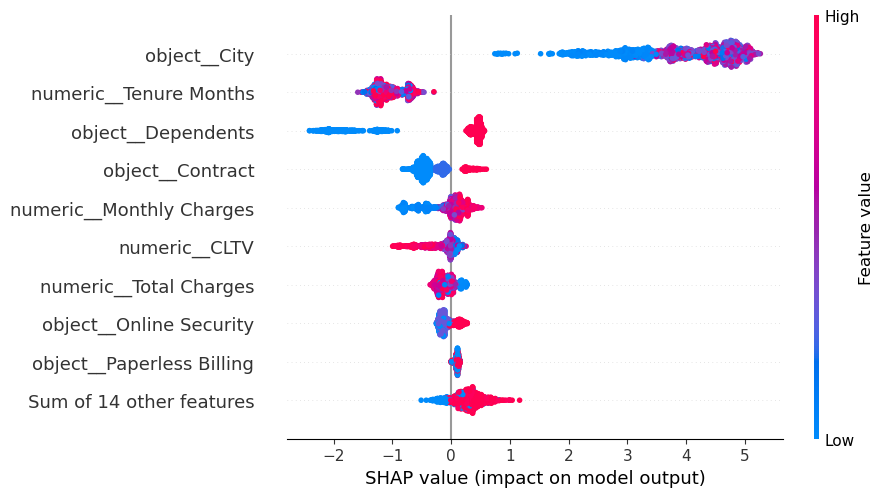

In [9]:
for m in trained_models_sm:
    shap_diagnostics(m.model, X_test_sm)

RandomForestClassifier


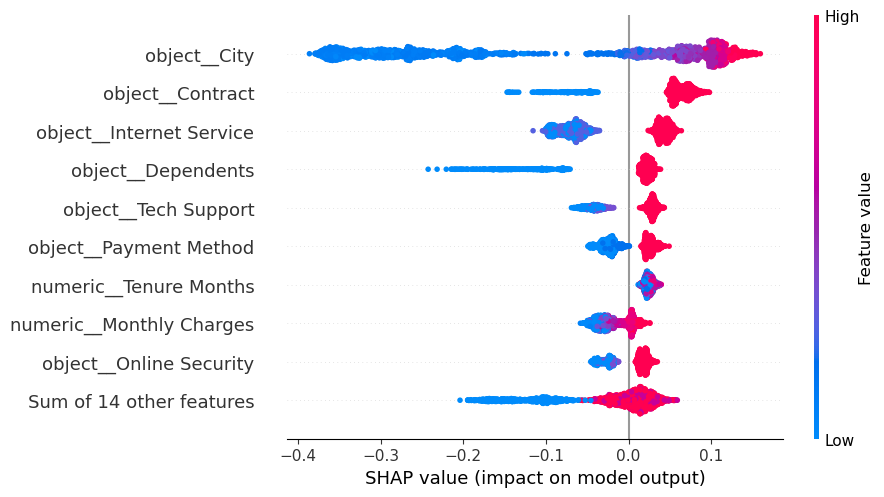

XGBClassifier


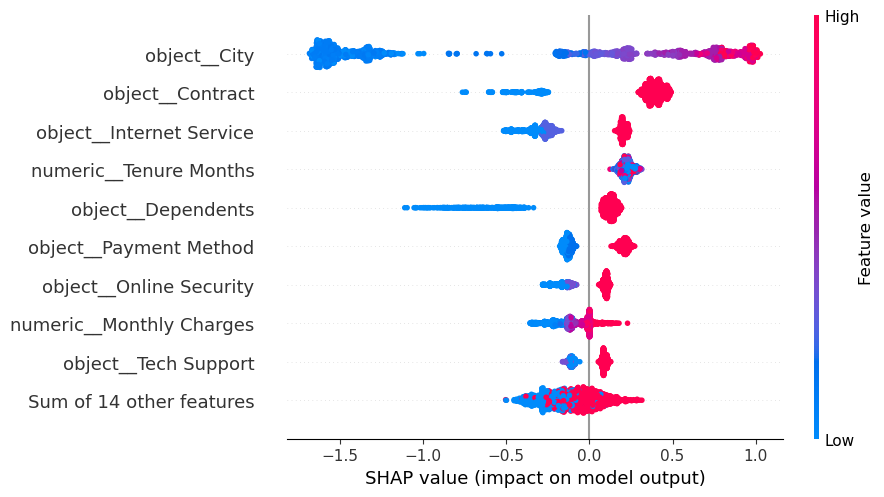

LGBMClassifier


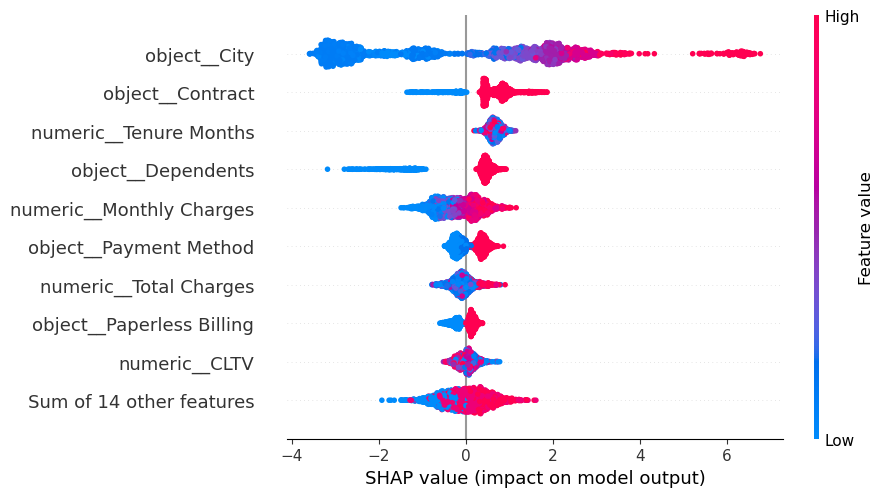

GradientBoostingClassifier


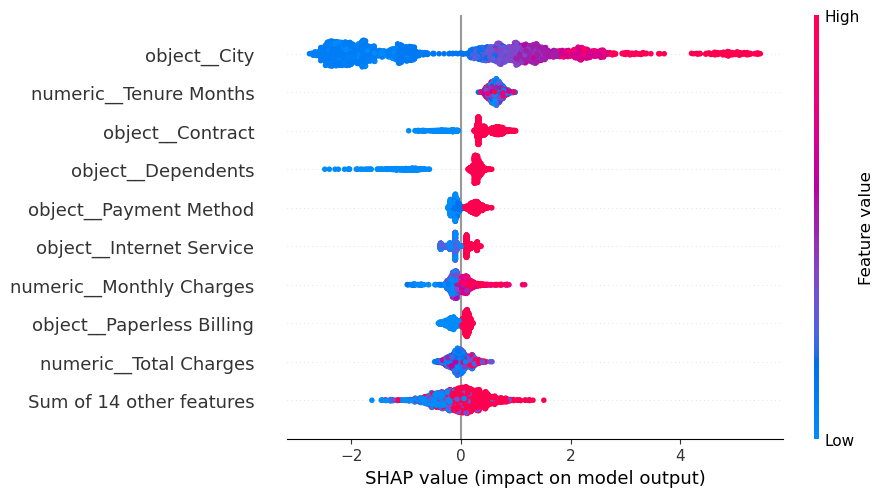

In [10]:
for m in trained_models_ml:
    shap_diagnostics(m.model, X_test_ml)

### 1.2 City

In [11]:
cities = ['Top_3','Top_3_to_15', 'Top_15_and_above']

test_cat_1 = ['Top_15_and_above']
test_cat_2 = ['Top_3']
split_criteria = ['City']
blacklist = cities + ['Latitude','Longitude'] + split_criteria

X_train_15, X_test_15, y_train_15, y_test_15, numeric_features, obj_features = preprocess_shift_categories_da(df_collection['City'],test_cat_1, blacklist)
X_train_3, X_test_3, y_train_3, y_test_3, numeric_features, obj_features = preprocess_shift_categories_da(df_collection['City'],test_cat_2, blacklist)

In [12]:
trained_models_t3 = train_models_da(model_list, X_train_15, X_test_15, y_train_15, y_test_15, 'Top_3')


Testing DecisionTree/RF on Top_3:
--- DecisionTree/RF Evaluation ---
              precision    recall  f1-score   support

           0       0.90      0.77      0.83      4300
           1       0.55      0.77      0.64      1540

    accuracy                           0.77      5840
   macro avg       0.72      0.77      0.74      5840
weighted avg       0.81      0.77      0.78      5840


Testing XGBoost on Top_3:
--- XGBoost Evaluation ---
              precision    recall  f1-score   support

           0       0.92      0.71      0.80      4300
           1       0.50      0.82      0.62      1540

    accuracy                           0.74      5840
   macro avg       0.71      0.76      0.71      5840
weighted avg       0.81      0.74      0.75      5840

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 329, number of negative: 874
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of t

In [13]:
trained_models_above_t15 = train_models_da(model_list, X_train_3, X_test_3, y_train_3, y_test_3, 'Top_15_and_above')


Testing DecisionTree/RF on Top_15_and_above:
--- DecisionTree/RF Evaluation ---
              precision    recall  f1-score   support

           0       0.89      0.77      0.83       398
           1       0.59      0.77      0.67       169

    accuracy                           0.77       567
   macro avg       0.74      0.77      0.75       567
weighted avg       0.80      0.77      0.78       567


Testing XGBoost on Top_15_and_above:
--- XGBoost Evaluation ---
              precision    recall  f1-score   support

           0       0.90      0.75      0.82       398
           1       0.58      0.80      0.67       169

    accuracy                           0.77       567
   macro avg       0.74      0.78      0.75       567
weighted avg       0.81      0.77      0.78       567

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1700, number of negative: 4776
[LightGBM] [Info] Auto-choosing row-wise multi-thre

### SHAP Diagnostics

RandomForestClassifier


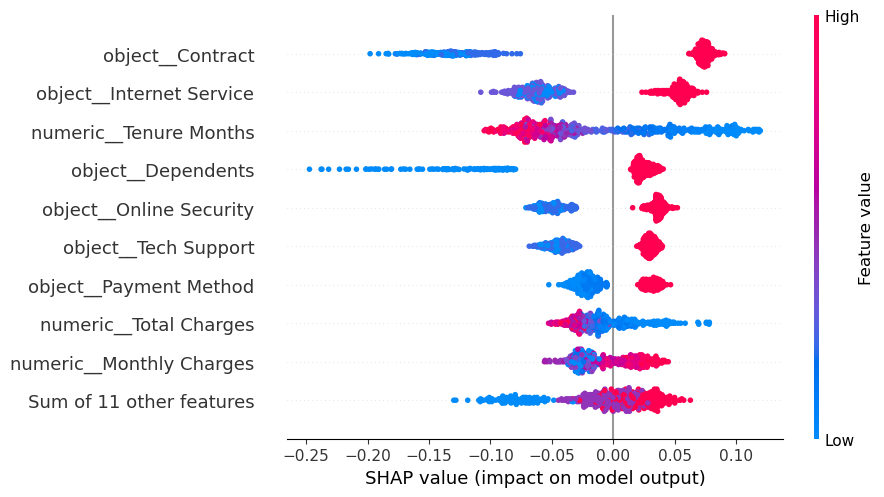

XGBClassifier


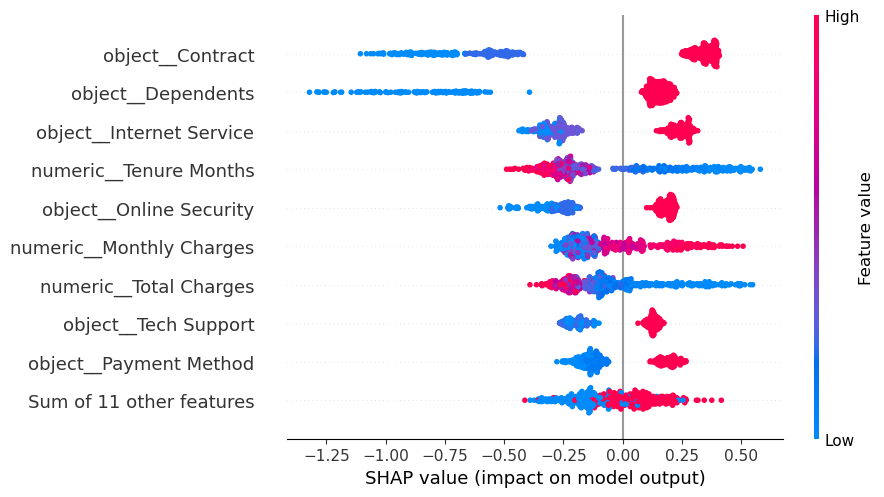

LGBMClassifier


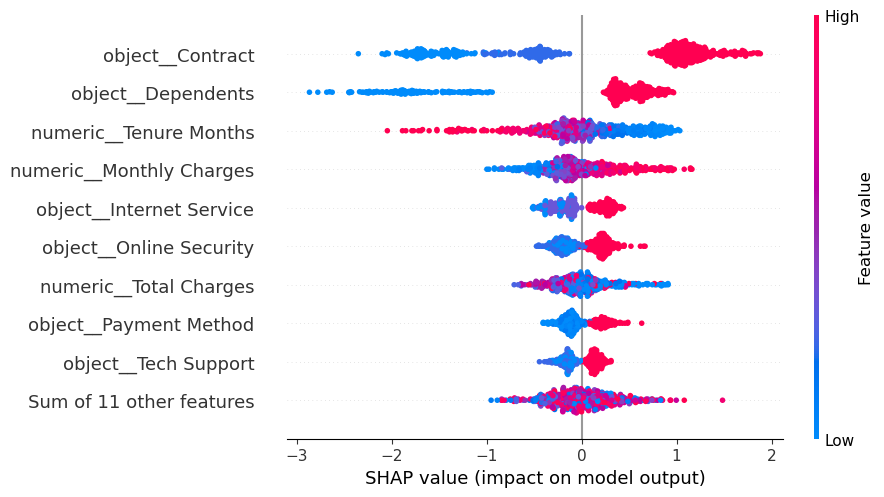

GradientBoostingClassifier


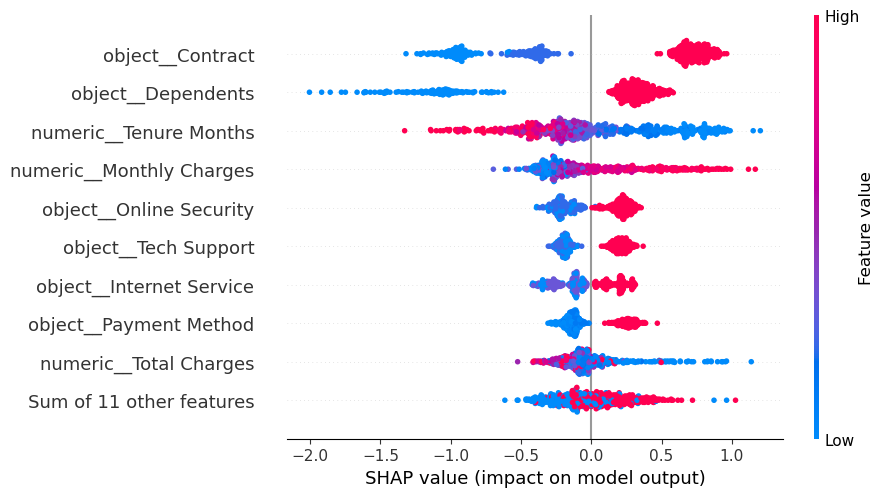

In [14]:
for m in trained_models_t3:
    shap_diagnostics(m.model, X_test_3)

RandomForestClassifier


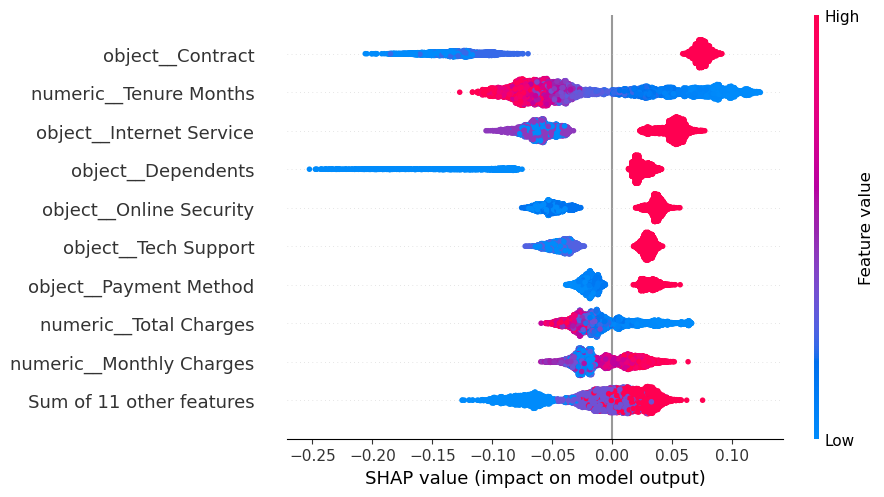

XGBClassifier


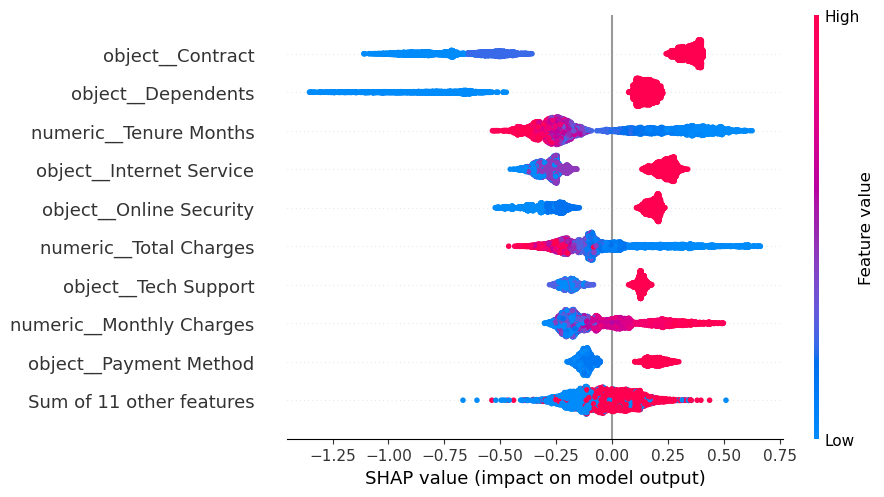

LGBMClassifier


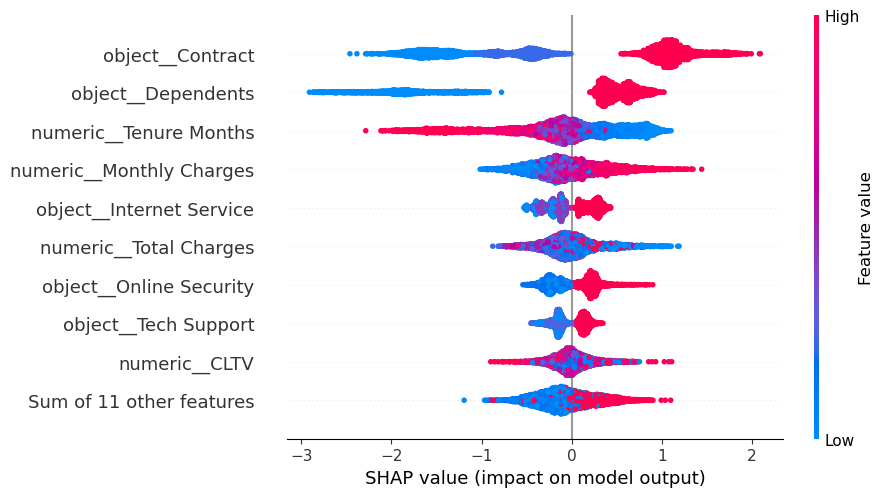

GradientBoostingClassifier


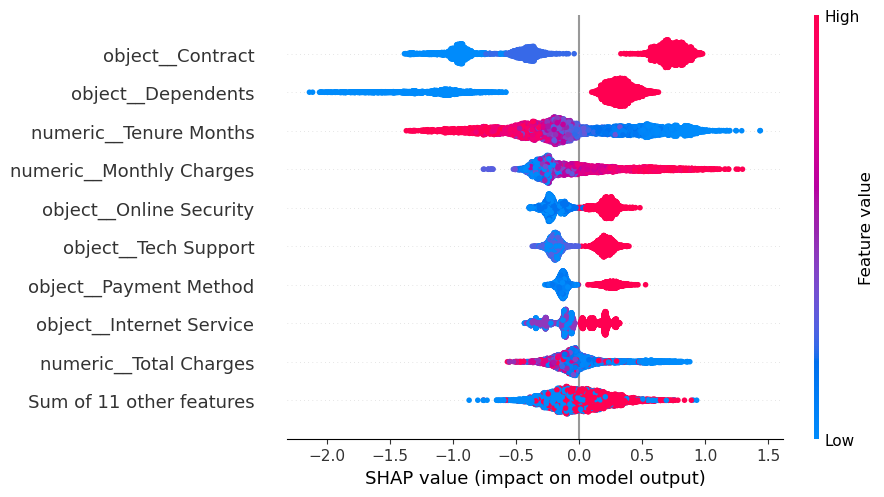

In [15]:
for m in trained_models_above_t15:
    shap_diagnostics(m.model, X_test_15)

### 1.3 Family Status

In [16]:
test_cat_1 = ['Male_No_No', 'Female_No_No']
test_cat_2 = ['Female_No_Yes','Male_No_Yes']
test_cat_3 = ['Male_Yes_Yes', 'Female_Yes_Yes']

split_criteria = ['Gender','Partner','Dependents']

blacklist = split_criteria + list(df_collection['Status'].keys())

X_train_s1, X_test_s1, y_train_s1, y_test_s1, numeric_features, obj_features =\
             preprocess_shift_categories_da(df_collection['Status'],test_cat_1, blacklist)
X_train_s2, X_test_s2, y_train_s2, y_test_s2, numeric_features, obj_features =\
             preprocess_shift_categories_da(df_collection['Status'],test_cat_2, blacklist)
X_train_s3, X_test_s3, y_train_s3, y_test_s3, numeric_features, obj_features =\
             preprocess_shift_categories_da(df_collection['Status'],test_cat_3, blacklist)

In [17]:
trained_models_s1 = train_models_da(model_list, X_train_s1, X_test_s1, y_train_s1, y_test_s1, 'Single People without Children')


Testing DecisionTree/RF on Single People without Children:
--- DecisionTree/RF Evaluation ---
              precision    recall  f1-score   support

           0       0.75      0.73      0.74      2189
           1       0.51      0.54      0.53      1150

    accuracy                           0.66      3339
   macro avg       0.63      0.63      0.63      3339
weighted avg       0.67      0.66      0.67      3339


Testing XGBoost on Single People without Children:
--- XGBoost Evaluation ---
              precision    recall  f1-score   support

           0       0.73      0.75      0.74      2189
           1       0.50      0.47      0.48      1150

    accuracy                           0.66      3339
   macro avg       0.62      0.61      0.61      3339
weighted avg       0.65      0.66      0.65      3339

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 719, number of negative: 2985
[LightGBM] [Info] Auto-c

In [18]:
trained_models_s2 = train_models_da(model_list, X_train_s2, X_test_s2, y_train_s2, y_test_s2, 'Single Moms/Dads')


Testing DecisionTree/RF on Single Moms/Dads:
--- DecisionTree/RF Evaluation ---
              precision    recall  f1-score   support

           0       0.94      0.72      0.81       252
           1       0.35      0.76      0.48        50

    accuracy                           0.73       302
   macro avg       0.64      0.74      0.65       302
weighted avg       0.84      0.73      0.76       302


Testing XGBoost on Single Moms/Dads:
--- XGBoost Evaluation ---
              precision    recall  f1-score   support

           0       0.93      0.73      0.82       252
           1       0.36      0.74      0.48        50

    accuracy                           0.74       302
   macro avg       0.65      0.74      0.65       302
weighted avg       0.84      0.74      0.77       302

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1819, number of negative: 4922
[LightGBM] [Info] Auto-choosing row-wise multi-thre

In [19]:
trained_models_s3 = train_models_da(model_list, X_train_s3, X_test_s3, y_train_s3, y_test_s3, 'Family People')


Testing DecisionTree/RF on Family People:
--- DecisionTree/RF Evaluation ---
              precision    recall  f1-score   support

           0       0.98      0.85      0.91      1269
           1       0.13      0.52      0.21        56

    accuracy                           0.84      1325
   macro avg       0.55      0.68      0.56      1325
weighted avg       0.94      0.84      0.88      1325


Testing XGBoost on Family People:
--- XGBoost Evaluation ---
              precision    recall  f1-score   support

           0       0.98      0.80      0.88      1269
           1       0.12      0.61      0.20        56

    accuracy                           0.79      1325
   macro avg       0.55      0.70      0.54      1325
weighted avg       0.94      0.79      0.85      1325

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1813, number of negative: 3905
[LightGBM] [Info] Auto-choosing row-wise multi-threading,

### SHAP Diagnostics

RandomForestClassifier


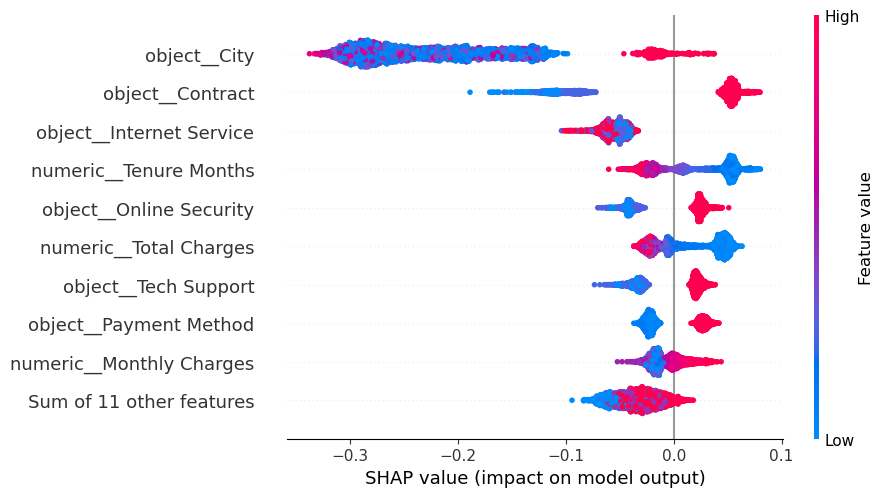

XGBClassifier


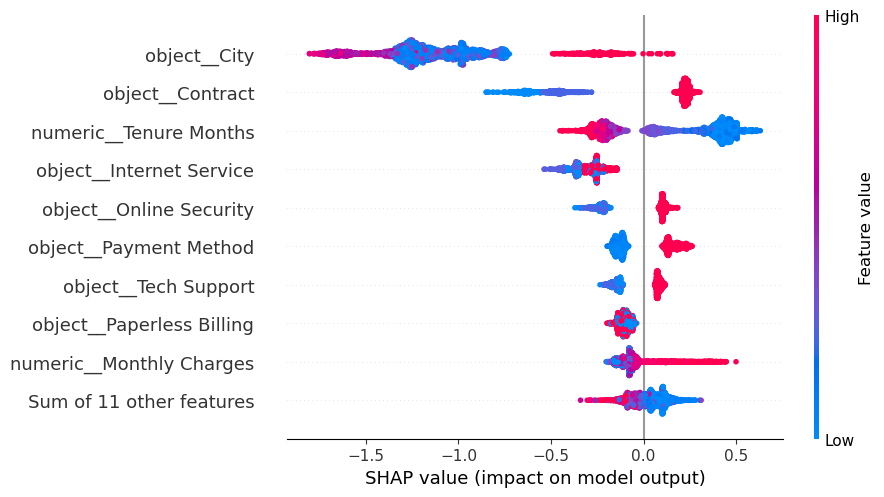

LGBMClassifier


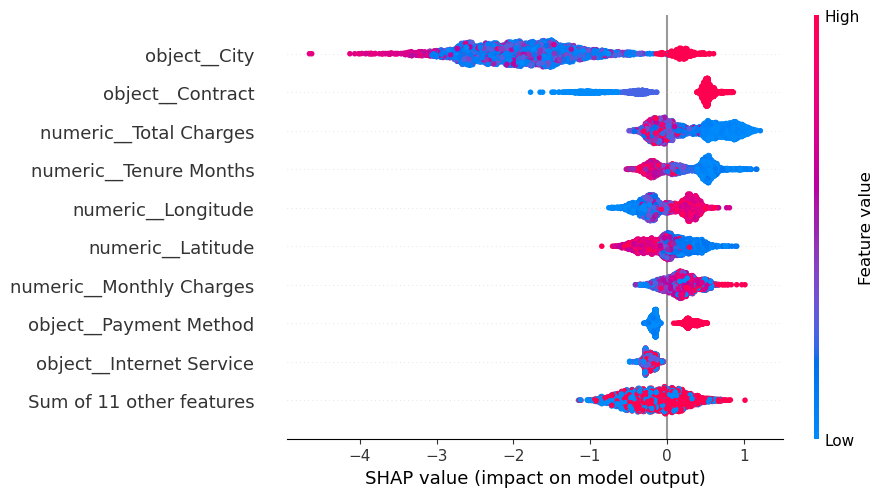

GradientBoostingClassifier


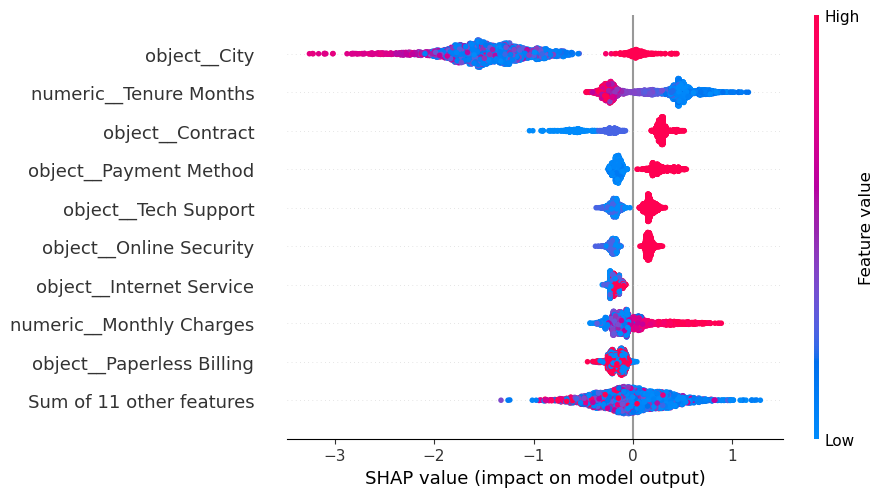

In [20]:
for m in trained_models_s1:
    shap_diagnostics(m.model, X_test_s1)

RandomForestClassifier


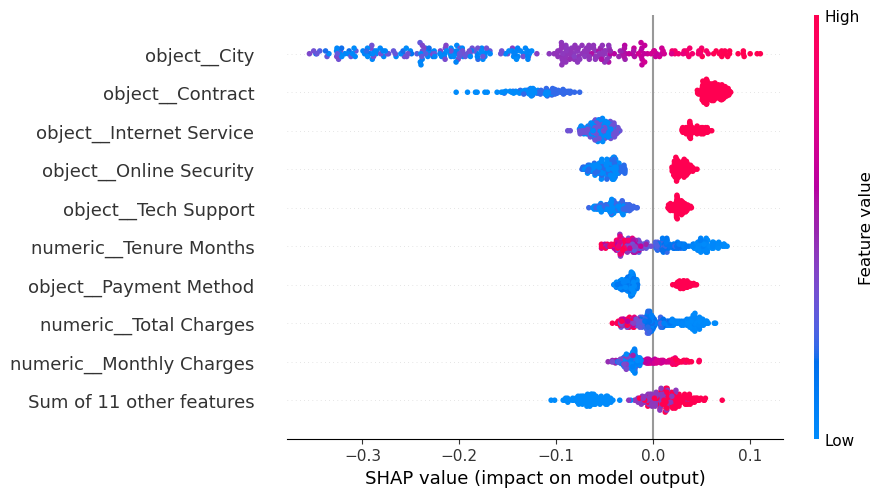

XGBClassifier


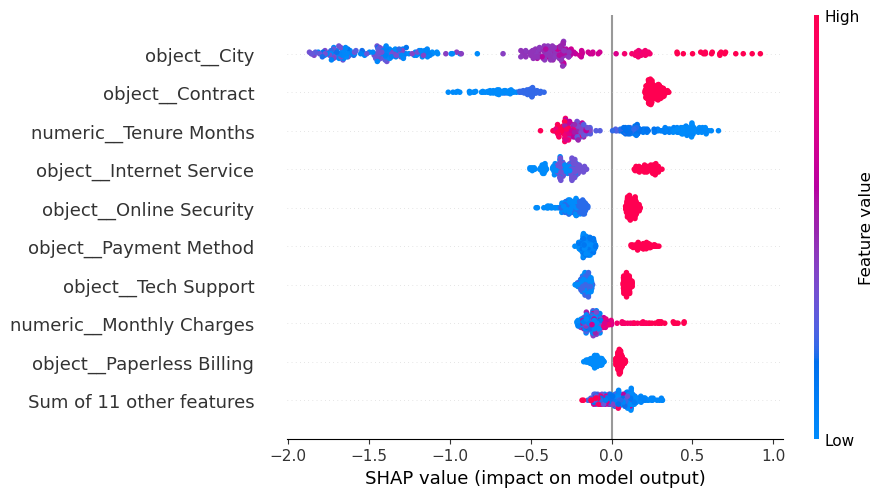

LGBMClassifier


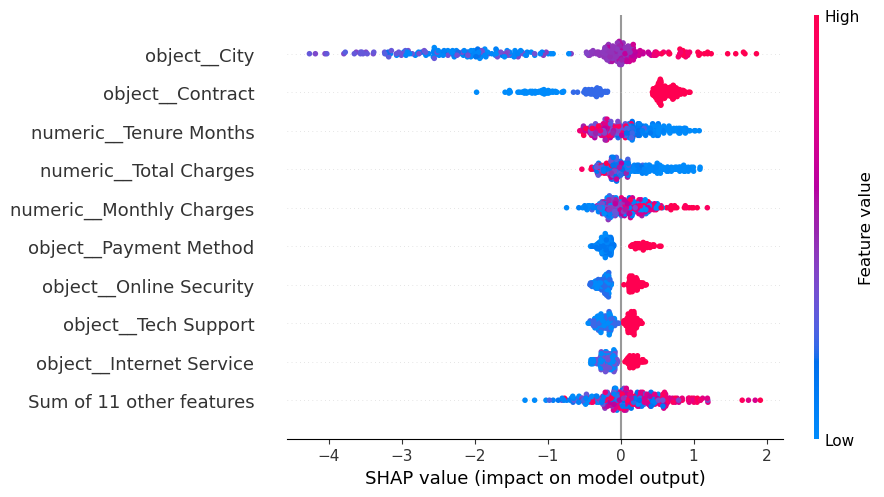

GradientBoostingClassifier


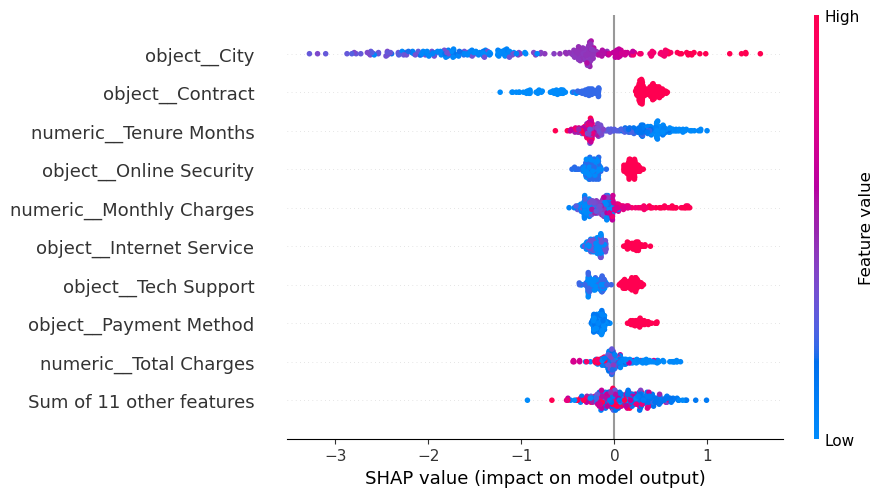

In [21]:
for m in trained_models_s2:
    shap_diagnostics(m.model, X_test_s2)

RandomForestClassifier


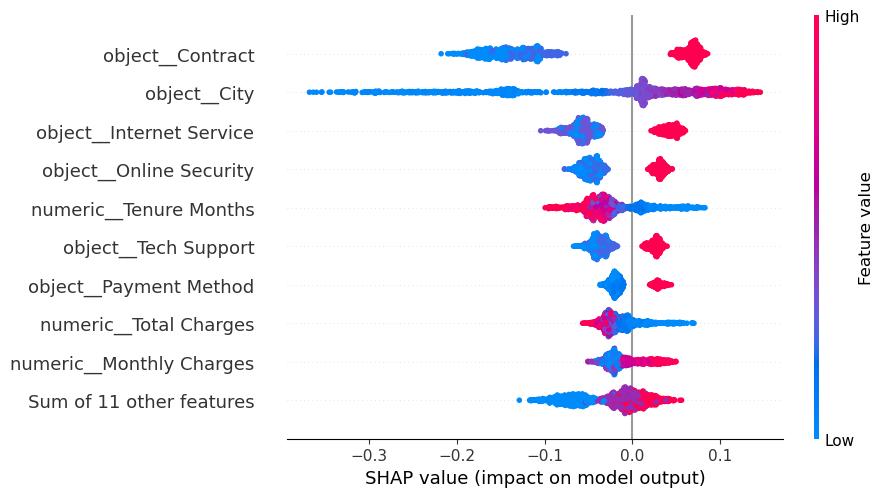

XGBClassifier


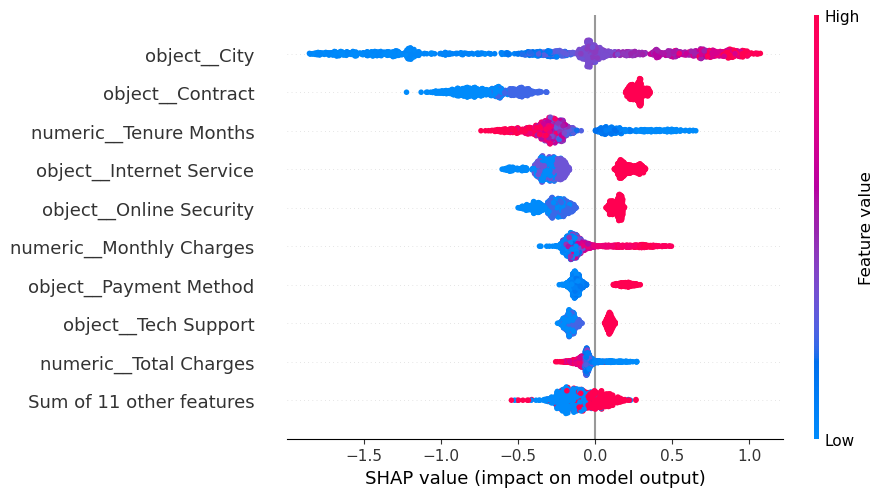

LGBMClassifier


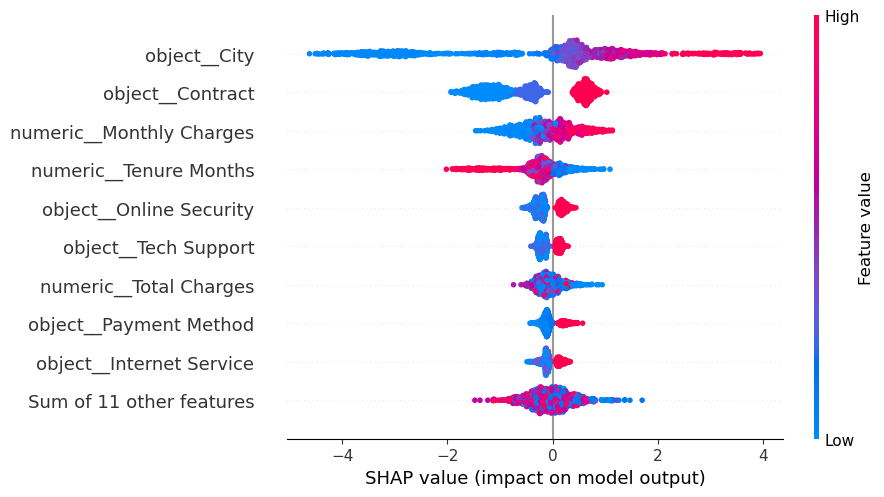

GradientBoostingClassifier


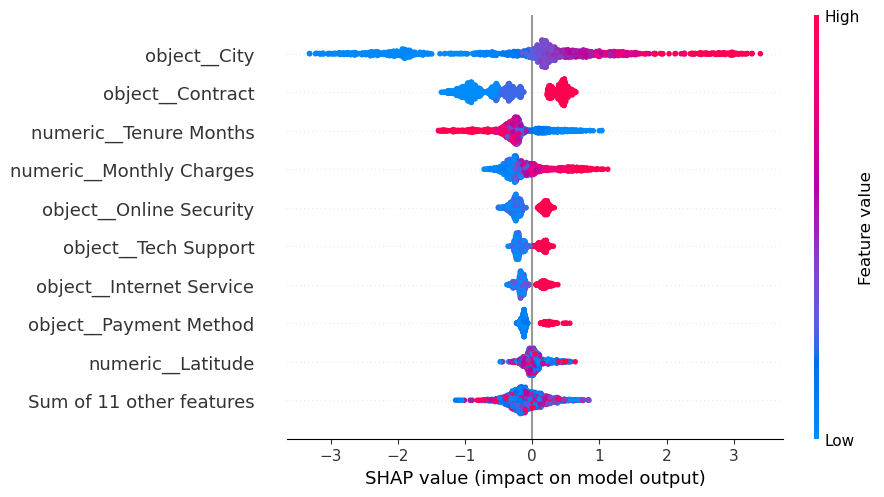

In [22]:
for m in trained_models_s3:
    shap_diagnostics(m.model, X_test_s3)

# 2. Subpopulation Analysis 

### 2.1 Tenure Cohort

### 2.2 City

### 2.3 Family Status